# ======================================================
# 🔹 Parametros para AC
# ======================================================

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 1️⃣ Cargar dataset
iris = sns.load_dataset("iris")
X = iris.drop(columns=["species"])

# 2️⃣ Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 📘 Parámetro: n_clusters

Define el número de clusters que el algoritmo debe formar.

A diferencia de KMeans:
- No existen centroides.
- Los clusters se forman fusionando grupos paso a paso.
- No hay atributo cluster_centers_.

En este ejemplo fijaremos n_clusters = 3.

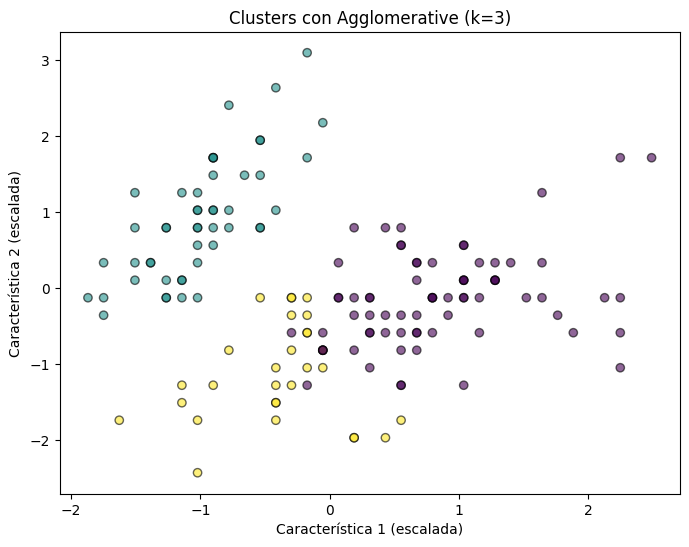

Coeficiente de Silueta para k=3: 0.4467


In [2]:
# 3️⃣ Definir número de clusters
k = 3

agg = AgglomerativeClustering(
    n_clusters=k,
    linkage="ward"   # minimiza varianza interna
)

labels = agg.fit_predict(X_scaled)

# 4️⃣ Visualización
plt.figure(figsize=(8,6))
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels,
    cmap='viridis',
    alpha=0.6,
    edgecolors='k'
)

plt.xlabel('Característica 1 (escalada)')
plt.ylabel('Característica 2 (escalada)')
plt.title(f'Clusters con Agglomerative (k={k})')
plt.show()

# 5️⃣ Silhouette Score
silhouette_value = silhouette_score(X_scaled, labels)
print(f'Coeficiente de Silueta para k={k}: {silhouette_value:.4f}')

# 📘 Parámetro: linkage

Define cómo se calcula la distancia entre clusters al fusionarlos.

Opciones más comunes:

- "ward" → minimiza varianza interna (solo euclidean)
- "complete" → distancia máxima
- "average" → distancia promedio
- "single" → distancia mínima (puede generar efecto cadena)

Aquí probaremos linkage="complete".

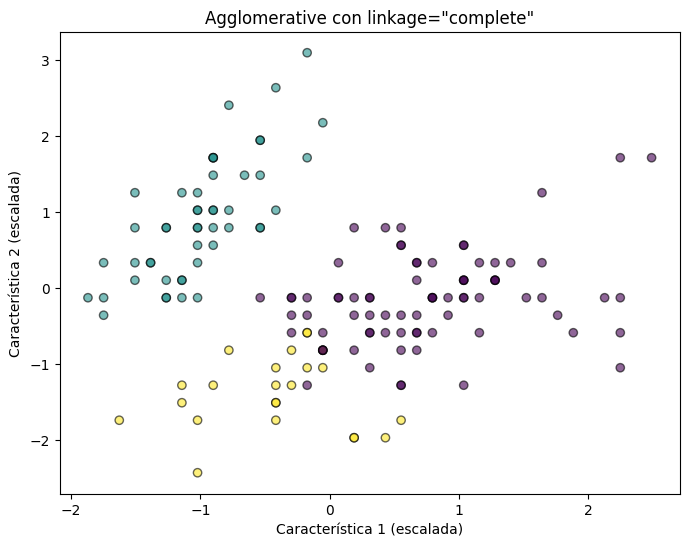

Silhouette Score: 0.4496


In [3]:
# ======================================================
# 🔹 Cambiando el método linkage
# ======================================================

k = 3

agg = AgglomerativeClustering(
    n_clusters=k,
    linkage="complete",
    metric="euclidean"
)

labels = agg.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels,
    cmap='viridis',
    alpha=0.6,
    edgecolors='k'
)

plt.xlabel('Característica 1 (escalada)')
plt.ylabel('Característica 2 (escalada)')
plt.title(f'Agglomerative con linkage="complete"')
plt.show()

silhouette_value = silhouette_score(X_scaled, labels)
print(f'Silhouette Score: {silhouette_value:.4f}')

# 📘 Parámetro: distance_threshold

Permite cortar el árbol jerárquico según una distancia
en lugar de definir directamente el número de clusters.

Cuando se usa:
- n_clusters debe ser None.

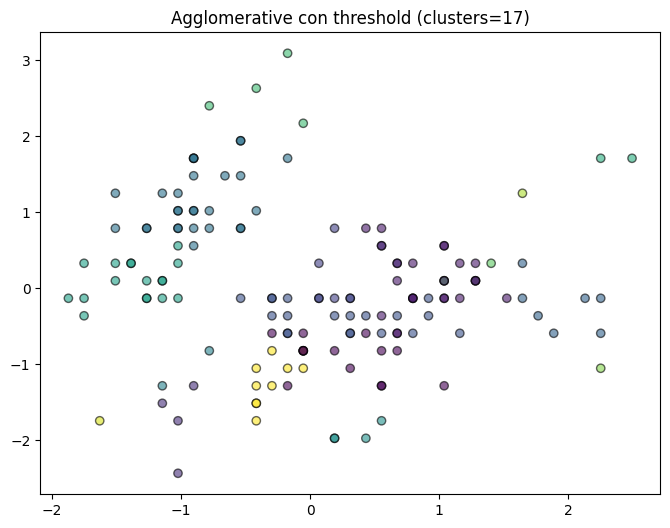

Silhouette Score: 0.3009


In [5]:
# ======================================================
# 🔹 Usando distance_threshold
# ======================================================

agg = AgglomerativeClustering(
    n_clusters=None,
    linkage="average",
    metric="euclidean",
    distance_threshold=1.0  # Añadir un valor para distance_threshold
)

labels = agg.fit_predict(X_scaled)

n_clusters_found = len(np.unique(labels))

plt.figure(figsize=(8,6))
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels,
    cmap='viridis',
    alpha=0.6,
    edgecolors='k'
)

plt.title(f'Agglomerative con threshold (clusters={n_clusters_found})')
plt.show()

if n_clusters_found > 1:
    silhouette_value = silhouette_score(X_scaled, labels)
    print(f'Silhouette Score: {silhouette_value:.4f}')